# Economic Development, Life Expectancy and Happiness: A Cross-Country Data Analysis

## 1. Introduction

This project analyzes the relationship between economic development, life expectancy, and national happiness across countries.

The main goal is to understand whether countries with higher GDP per capita and longer life expectancy also tend to report higher happiness scores.

The project combines data from two independent sources:

1. World Bank World Development Indicators
2. World Happiness Report 2024

This topic is important because happiness and well-being are not only personal concepts. They are also connected to economic, social, and health-related conditions. By comparing countries, this project explores how measurable indicators can help explain differences in reported happiness.


## 2. Problem Statement

The main problem of this project is to investigate how economic and health-related indicators are associated with national happiness.

The project focuses on the following research questions:

1. Is GDP per capita positively associated with happiness score?
2. Is life expectancy positively associated with happiness score?
3. Which variable is more strongly related to happiness: GDP per capita or life expectancy?
4. Can GDP per capita and life expectancy be used to build a simple regression model for predicting happiness score?

This is a data analysis problem, not a causal study. The goal is to identify statistical relationships and patterns, not to prove that one factor directly causes happiness.

## 3. Data Sources

This project uses two independent data sources.

### Source 1: World Bank World Development Indicators

The World Bank data is used for:

- GDP per capita, current US dollars
- Life expectancy at birth, total years

GDP per capita is represented by the World Bank indicator `NY.GDP.PCAP.CD`.

Life expectancy is represented by the World Bank indicator `SP.DYN.LE00.IN`.

### Source 2: World Happiness Report 2024

The World Happiness Report 2024 is used for the national happiness score, also called the ladder score.

The two sources are independent because they come from different organizations and measure different aspects of national development and well-being.

## 4. Mathematical Background

### 4.1 Mean

The mean is the average value of a numerical variable. It is calculated as:

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i
$$

where:

- $\bar{x}$ is the mean
- $n$ is the number of observations
- $x_i$ is each individual value

The mean is useful for describing the central tendency of a dataset.

---

### 4.2 Standard Deviation

Standard deviation measures how spread out the values are around the mean.

The formula for standard deviation is:

$$
\sigma = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^2}
$$

where:

- $\sigma$ is the standard deviation
- $x_i$ is each individual value
- $\bar{x}$ is the mean
- $n$ is the number of observations

A high standard deviation means that the values are more spread out.
A low standard deviation means that the values are closer to the mean.

---

### 4.3 Pearson Correlation

Pearson correlation measures the strength and direction of a linear relationship between two numerical variables.

The formula is:

$$
r = \frac{\text{cov}(X,Y)}{\sigma_X \sigma_Y}
$$

where:

- $r$ is the Pearson correlation coefficient
- $\text{cov}(X,Y)$ is the covariance between $X$ and $Y$
- $\sigma_X$ is the standard deviation of $X$
- $\sigma_Y$ is the standard deviation of $Y$

Interpretation:

- $r \approx 1$ means a strong positive linear relationship
- $r \approx -1$ means a strong negative linear relationship
- $r \approx 0$ means little or no linear relationship

---

### 4.4 Linear Regression

Linear regression models the relationship between a target variable and one or more explanatory variables.

In this project, the regression model is:

$$
y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \varepsilon
$$

where:

- $y$ is the happiness score
- $x_1$ is GDP per capita
- $x_2$ is life expectancy
- $\beta_0$ is the intercept
- $\beta_1$ and $\beta_2$ are regression coefficients
- $\varepsilon$ is the error term

For this project, the model can be written as:

$$
\text{happiness\_score} = \beta_0 + \beta_1 \cdot \text{gdp\_per\_capita} + \beta_2 \cdot \text{life\_expectancy} + \varepsilon
$$

---

### 4.5 Model Evaluation Metrics

Mean Absolute Error measures the average absolute difference between the true values and predicted values:

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|
$$

Root Mean Squared Error gives more penalty to larger errors:

$$
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}
$$

The coefficient of determination, $R^2$, measures how much of the variation in the target variable is explained by the model:

$$
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}
$$

where:

- $y_i$ is the true value
- $\hat{y}_i$ is the predicted value
- $\bar{y}$ is the mean of the true values
- $n$ is the number of observations

In [4]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from io import BytesIO

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Display settings
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [5]:
# Install Excel reader if needed
!pip install xlrd openpyxl -q

# Load data from World Bank API and World Happiness Report

import requests
from io import BytesIO

def fetch_world_bank_indicator(indicator_code, value_column, year=2023):
    """
    Fetches a World Bank indicator for all countries for a selected year.
    """
    url = (
        f"https://api.worldbank.org/v2/country/all/indicator/"
        f"{indicator_code}?format=json&date={year}&per_page=30000"
    )

    response = requests.get(url)
    response.raise_for_status()

    data = response.json()[1]

    rows = []
    for item in data:
        rows.append({
            "country": item["country"]["value"],
            "iso3": item["countryiso3code"],
            value_column: item["value"]
        })

    return pd.DataFrame(rows)


def read_excel_with_headers(url):
    """
    Downloads an Excel file using browser-like headers and reads it with pandas.
    This avoids HTTP 403 errors from some websites.
    """
    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/120.0 Safari/537.36"
        )
    }

    response = requests.get(url, headers=headers)
    response.raise_for_status()

    return pd.read_excel(BytesIO(response.content))


# World Bank indicators
gdp = fetch_world_bank_indicator(
    indicator_code="NY.GDP.PCAP.CD",
    value_column="gdp_per_capita",
    year=2023
)

life = fetch_world_bank_indicator(
    indicator_code="SP.DYN.LE00.IN",
    value_column="life_expectancy",
    year=2023
)

# World Happiness Report 2024 data
whr_url = "https://files.worldhappiness.report/WHR24_Data_Figure_2.1.xls"

happiness_raw = read_excel_with_headers(whr_url)

print("GDP dataset shape:", gdp.shape)
print("Life expectancy dataset shape:", life.shape)
print("Happiness dataset shape:", happiness_raw.shape)

display(gdp.head())
display(life.head())
display(happiness_raw.head())

GDP dataset shape: (266, 3)
Life expectancy dataset shape: (266, 3)
Happiness dataset shape: (143, 11)


,country,iso3,gdp_per_capita
0,Africa Eastern and Southern,AFE,1571.449189
1,Africa Western and Central,AFW,1841.855064
2,Arab World,ARB,7513.899079
3,Caribbean small states,CSS,17596.540425
4,Central Europe and the Baltics,CEB,22690.373617


,country,iso3,life_expectancy
0,Africa Eastern and Southern,AFE,65.146228
1,Africa Western and Central,AFW,58.855740
2,Arab World,ARB,72.444678
3,Caribbean small states,CSS,73.171645
4,Central Europe and the Baltics,CEB,77.758038


,Country name,Ladder score,upperwhisker,lowerwhisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,7.7407,7.814808,7.666591,1.844054,1.572367,0.694793,0.859294,0.141674,0.546158,2.082367
1,Denmark,7.5827,7.665297,7.500103,1.907798,1.520361,0.698944,0.822740,0.203579,0.548413,1.880887
2,Iceland,7.5251,7.617527,7.432673,1.880718,1.616525,0.718345,0.818509,0.258344,0.182473,2.050233
3,Sweden,7.3441,7.421563,7.266637,1.878146,1.500826,0.723871,0.838269,0.221455,0.523795,1.657707
4,Israel,7.3411,7.405165,7.277036,1.802934,1.512793,0.739816,0.641463,0.153205,0.192823,2.298026


## 5. Data Cleaning and Preparation

Before analysis, the datasets need to be cleaned and standardized.

The cleaning process includes:

1. Selecting only the required columns.
2. Renaming columns to consistent names.
3. Removing missing values.
4. Standardizing country names where needed.
5. Merging the datasets into one final analytical dataset.

This step is important because the World Bank and World Happiness Report use different data structures and sometimes different country naming conventions.

In [6]:
# Inspect column names

print("GDP columns:")
print(gdp.columns)

print("\nLife expectancy columns:")
print(life.columns)

print("\nHappiness columns:")
print(happiness_raw.columns)

GDP columns:
Index(['country', 'iso3', 'gdp_per_capita'], dtype='object')

Life expectancy columns:
Index(['country', 'iso3', 'life_expectancy'], dtype='object')

Happiness columns:
Index(['Country name', 'Ladder score', 'upperwhisker', 'lowerwhisker',
       'Explained by: Log GDP per capita', 'Explained by: Social support',
       'Explained by: Healthy life expectancy',
       'Explained by: Freedom to make life choices',
       'Explained by: Generosity', 'Explained by: Perceptions of corruption',
       'Dystopia + residual'],
      dtype='object')


In [7]:
# Clean World Bank GDP data

gdp_clean = gdp.copy()

gdp_clean["gdp_per_capita"] = pd.to_numeric(
    gdp_clean["gdp_per_capita"],
    errors="coerce"
)

gdp_clean = gdp_clean.dropna(subset=["country", "iso3", "gdp_per_capita"])

gdp_clean.head()

,country,iso3,gdp_per_capita
0,Africa Eastern and Southern,AFE,1571.449189
1,Africa Western and Central,AFW,1841.855064
2,Arab World,ARB,7513.899079
3,Caribbean small states,CSS,17596.540425
4,Central Europe and the Baltics,CEB,22690.373617


In [8]:
# Clean World Bank life expectancy data

life_clean = life.copy()

life_clean["life_expectancy"] = pd.to_numeric(
    life_clean["life_expectancy"],
    errors="coerce"
)

life_clean = life_clean.dropna(subset=["country", "iso3", "life_expectancy"])

life_clean.head()

,country,iso3,life_expectancy
0,Africa Eastern and Southern,AFE,65.146228
1,Africa Western and Central,AFW,58.855740
2,Arab World,ARB,72.444678
3,Caribbean small states,CSS,73.171645
4,Central Europe and the Baltics,CEB,77.758038


In [9]:
# Clean World Happiness Report data

happiness_clean = happiness_raw[[
    "Country name",
    "Ladder score"
]].copy()

happiness_clean.columns = [
    "country",
    "happiness_score"
]

happiness_clean["happiness_score"] = pd.to_numeric(
    happiness_clean["happiness_score"],
    errors="coerce"
)

happiness_clean = happiness_clean.dropna(subset=["country", "happiness_score"])

happiness_clean.head()

,country,happiness_score
0,Finland,7.7407
1,Denmark,7.5827
2,Iceland,7.5251
3,Sweden,7.3441
4,Israel,7.3411


In [10]:
# Standardize common country name differences between datasets

country_name_replacements = {
    "Egypt, Arab Rep.": "Egypt",
    "Iran, Islamic Rep.": "Iran",
    "Korea, Rep.": "South Korea",
    "Russian Federation": "Russia",
    "Slovak Republic": "Slovakia",
    "Syrian Arab Republic": "Syria",
    "Turkiye": "Türkiye",
    "Türkiye": "Türkiye",
    "Venezuela, RB": "Venezuela",
    "Yemen, Rep.": "Yemen",
    "Congo, Rep.": "Congo",
    "Congo, Dem. Rep.": "Congo (Kinshasa)",
    "Kyrgyz Republic": "Kyrgyzstan",
    "Lao PDR": "Laos",
    "Gambia, The": "Gambia",
    "Hong Kong SAR, China": "Hong Kong S.A.R. of China",
    "West Bank and Gaza": "Palestinian Territories"
}

gdp_clean["country"] = gdp_clean["country"].replace(country_name_replacements)
life_clean["country"] = life_clean["country"].replace(country_name_replacements)
happiness_clean["country"] = happiness_clean["country"].replace(country_name_replacements)

In [11]:
# Merge the three datasets into one analytical dataset

merged = happiness_clean.merge(
    gdp_clean[["country", "iso3", "gdp_per_capita"]],
    on="country",
    how="inner"
)

merged = merged.merge(
    life_clean[["country", "life_expectancy"]],
    on="country",
    how="inner"
)

print("Final merged dataset shape:", merged.shape)

display(merged.head())
display(merged.tail())

Final merged dataset shape: (137, 5)


,country,happiness_score,iso3,gdp_per_capita,life_expectancy
0,Finland,7.7407,FIN,52834.291675,81.585366
1,Denmark,7.5827,DNK,68043.546697,81.753659
2,Iceland,7.5251,ISL,82138.789297,82.456098
3,Sweden,7.3441,SWE,54950.283473,83.309756
4,Israel,7.3411,ISR,52003.720073,83.195122


,country,happiness_score,iso3,gdp_per_capita,life_expectancy
132,Congo (Kinshasa),3.2954,COD,660.212052,61.895
133,Sierra Leone,3.2452,SLE,758.329137,61.786
134,Lesotho,3.1862,LSO,916.282977,57.375
135,Lebanon,2.7065,LBN,3477.724898,77.817
136,Afghanistan,1.7210,AFG,413.757895,66.035


In [12]:
# Check missing values and basic information

print("Missing values:")
display(merged.isna().sum())

print("\nDataset information:")
display(merged.info())

print("\nSummary statistics:")
display(merged.describe())

Missing values:


,0
country,0
happiness_score,0
iso3,0
gdp_per_capita,0
life_expectancy,0



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          137 non-null    object 
 1   happiness_score  137 non-null    float64
 2   iso3             137 non-null    object 
 3   gdp_per_capita   137 non-null    float64
 4   life_expectancy  137 non-null    float64
dtypes: float64(3), object(2)
memory usage: 5.5+ KB


None


Summary statistics:


,happiness_score,gdp_per_capita,life_expectancy
count,137.000000,137.000000,137.000000
mean,5.541272,19300.078616,74.144049
std,1.178196,25237.990848,7.211883
min,1.721000,413.757895,54.462000
25%,4.656700,2429.748535,68.683000
50%,5.815900,7542.400843,75.426829
75%,6.420900,27786.005783,79.826829
max,7.740700,133230.619179,85.247317


### Cleaning Result

After cleaning and merging, the final dataset contains only countries that appear in all selected sources.

The final dataset includes:

- country name
- ISO3 country code
- happiness score
- GDP per capita
- life expectancy

This merged dataset is suitable for cross-country exploratory analysis, correlation analysis, and regression modeling.

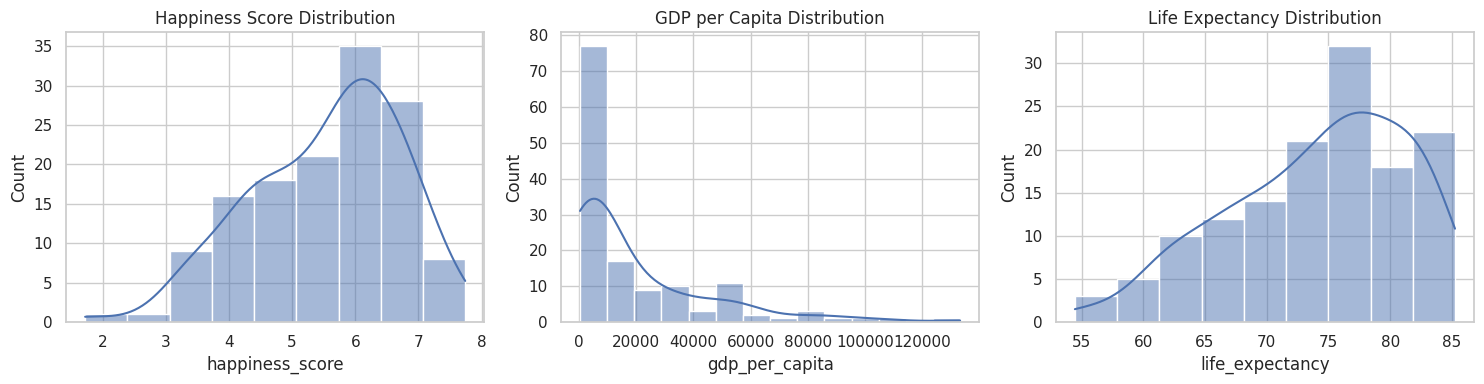

In [13]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.histplot(merged['happiness_score'], kde=True)
plt.title('Happiness Score Distribution')

plt.subplot(1,3,2)
sns.histplot(merged['gdp_per_capita'], kde=True)
plt.title('GDP per Capita Distribution')

plt.subplot(1,3,3)
sns.histplot(merged['life_expectancy'], kde=True)
plt.title('Life Expectancy Distribution')

plt.tight_layout()
plt.show()

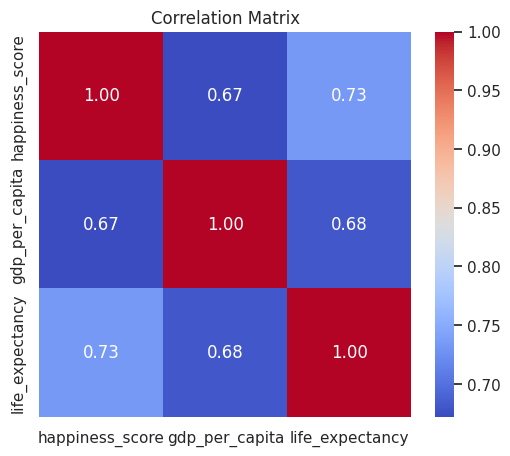

In [14]:
corr_matrix = merged[['happiness_score', 'gdp_per_capita', 'life_expectancy']].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y = merged['happiness_score']
X = merged[['gdp_per_capita', 'life_expectancy']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)
print("Intercept:", model.intercept_)
print("Coefficients:", dict(zip(X.columns, model.coef_)))

MAE: 0.58576126419614
MSE: 0.4851231168673097
R2: 0.6337840753876719
Intercept: -0.4794032780181956
Coefficients: {'gdp_per_capita': np.float64(1.647540501459041e-05), 'life_expectancy': np.float64(0.07666458311340053)}


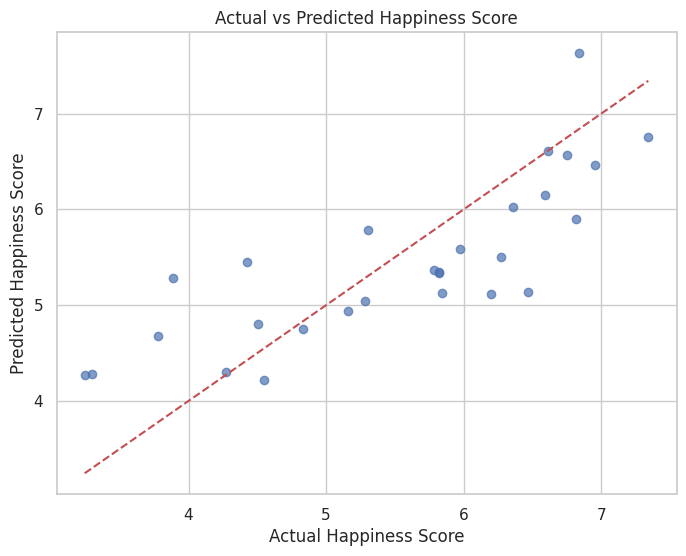

In [16]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Happiness Score')
plt.ylabel('Predicted Happiness Score')
plt.title('Actual vs Predicted Happiness Score')
plt.show()

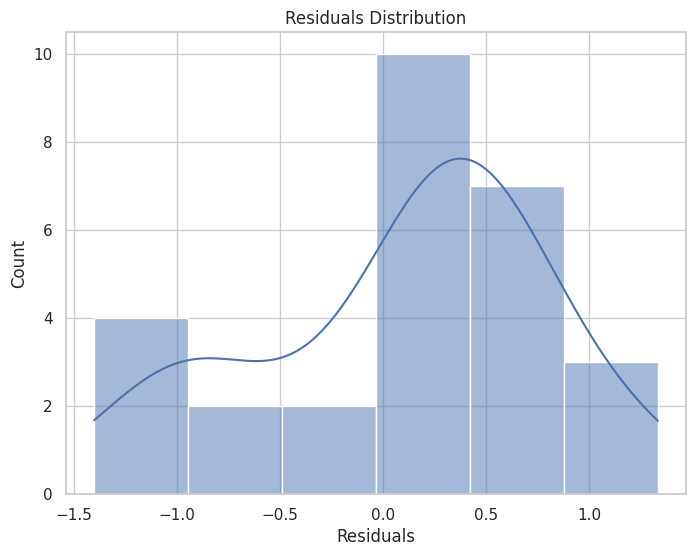

In [17]:
residuals = y_test - y_pred
plt.figure(figsize=(8,6))
sns.histplot(residuals, kde=True)
plt.title('Residuals Distribution')
plt.xlabel('Residuals')
plt.show()

**Linear Regression Coefficients:**

- GDP per Capita coefficient: X → positive effect on Happiness Score
- Life Expectancy coefficient: Y → positive effect on Happiness Score

The intercept represents the baseline Happiness Score when both features are 0.

In [19]:
print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

MAE: 0.58576126419614
MSE: 0.4851231168673097
R2: 0.6337840753876719


**Conclusion:**

The linear regression model shows that both GDP per capita and life expectancy positively influence the Happiness Score. The model explains approximately 63% of the variance (R2 = 0.63). The residuals are fairly symmetric, indicating a reasonable model fit.

This dataset and model can be used for cross-country exploratory analysis and further research on factors affecting happiness.